In [109]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [110]:
#DACH data frame

DACH_countries = ["Germany","Austria","Switzerland","Luxembourg"]

df_DACH = df[df["job_country"].isin(DACH_countries)].copy()

In [111]:
#Expand/Explode list job_skills into seperate rows

df_DACH_expl = df_DACH.explode("job_skills")

In [112]:
#Create Series with numer of postings grouped by job skills and job title short

df_DACH_skillcount = df_DACH_expl.groupby(["job_skills","job_title_short"]).size()

In [113]:
#Turn series into DF by reseting its index

df_DACH_skillcount = df_DACH_skillcount.reset_index(name="skill_count")

In [115]:
#Sort skill count column in desc order

df_DACH_skillcount.sort_values(by="skill_count",ascending=False,inplace=True)

In [116]:
# Create filter for top 3 job titles (short)

job_titles = df_DACH_skillcount["job_title_short"].unique().tolist()

job_titles = sorted(job_titles[:3])

In [117]:
#Count total postings for each job in job titles and saving results

df_DACH_totaljobs = (df_DACH["job_title_short"]
                     .value_counts(ascending=False)
                     #.head(3)
                     .reset_index(name="total_skill_count")
                     )

In [118]:
#Merge total jobs DF with skill count DF

df_DACH_skilljob_merge = df_DACH_skillcount.merge(right=df_DACH_totaljobs,how="left",on="job_title_short")

In [120]:
#Create new column for skill mentions in total job postings (in %)

df_DACH_skilljob_merge["skill_share"] = 100*(df_DACH_skilljob_merge["skill_count"]/df_DACH_skilljob_merge["total_skill_count"])

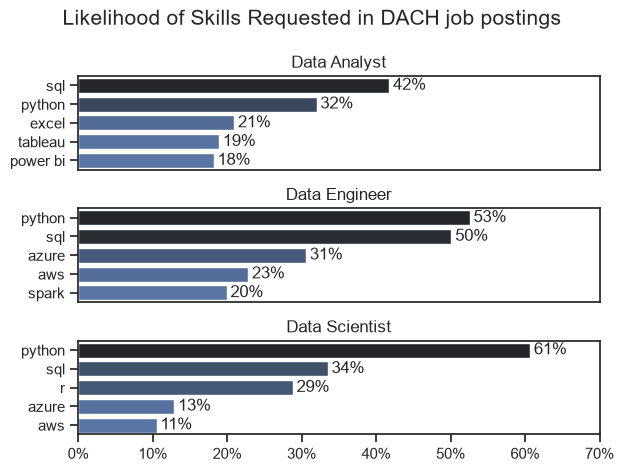

In [122]:
#Visualize results using subplots (using %)

fig,ax = plt.subplots(len(job_titles),1)

sns.set_theme(style="ticks")

for i,title in enumerate(job_titles):
    df_DACH_skilljob_plot = df_DACH_skilljob_merge[df_DACH_skilljob_merge["job_title_short"]==title].head(5)

    #df_DACH_skilljob_plot.plot(kind="barh",x="job_skills",y="skill_share",ax=ax[i],title=title)
    sns.barplot(data=df_DACH_skilljob_plot,x="skill_share",y="job_skills",ax=ax[i],hue="skill_count",palette="dark:b_r")
    #ax[i].invert_yaxis()
    ax[i].set_title(title)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,70)
    if i != len(job_titles)-1:
        ax[i].set_xticks([])

    for j,val in enumerate(df_DACH_skilljob_plot["skill_share"]):
        ax[i].text(val+0.5,j,f"{val:.0f}%",va="center")
        ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{int(x)}%"))



fig.suptitle("Likelihood of Skills Requested in DACH job postings",fontsize=15)
fig.tight_layout()
plt.show()